Imports

In [1]:
from pathlib import Path
import sys
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("✓ Imports completed successfully.")

✓ Imports completed successfully.


Project paths

In [2]:
PROJECT_PATH = Path(r"E:\ML_Project")
DATASET_PATH = PROJECT_PATH / "datasets" / "bdd100k_original_yolo"

TRAIN_PATH = DATASET_PATH / "train"
VALID_PATH = DATASET_PATH / "valid"
TEST_PATH = DATASET_PATH / "test"
RESULTS_PATH = PROJECT_PATH / "results"

# Frozen YOLO26n baseline checkpoint
MODEL_PATH = (
    RESULTS_PATH
    / "yolo26_baseline"
    / "bdd100k_original_yolo_yolo26n_baseline_30ep"
    / "weights"
    / "best.pt"
)

# Notebook 8 output directory
ORACLE_PATH = RESULTS_PATH / "oracle_labels"
ORACLE_PATH.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("PROJECT CONFIGURATION")
print("=" * 70)
print(f"Dataset : {DATASET_PATH}")
print(f"Train   : {TRAIN_PATH}")
print(f"Valid   : {VALID_PATH}")
print(f"Test    : {TEST_PATH}")
print(f"Model   : {MODEL_PATH}")
print(f"Output  : {ORACLE_PATH}")
print("=" * 70)

assert DATASET_PATH.exists(), f"Dataset not found: {DATASET_PATH}"
assert MODEL_PATH.exists(), f"YOLO26n checkpoint not found: {MODEL_PATH}"

print("✓ Dataset found")
print("✓ Frozen YOLO26n checkpoint found")

PROJECT CONFIGURATION
Dataset : E:\ML_Project\datasets\bdd100k_original_yolo
Train   : E:\ML_Project\datasets\bdd100k_original_yolo\train
Valid   : E:\ML_Project\datasets\bdd100k_original_yolo\valid
Test    : E:\ML_Project\datasets\bdd100k_original_yolo\test
Model   : E:\ML_Project\results\yolo26_baseline\bdd100k_original_yolo_yolo26n_baseline_30ep\weights\best.pt
Output  : E:\ML_Project\results\oracle_labels
✓ Dataset found
✓ Frozen YOLO26n checkpoint found


Load YOLO26n

In [3]:
model = YOLO(str(MODEL_PATH))

print("✓ YOLO26n model loaded.")
print(f"Checkpoint: {MODEL_PATH}")

✓ YOLO26n model loaded.
Checkpoint: E:\ML_Project\results\yolo26_baseline\bdd100k_original_yolo_yolo26n_baseline_30ep\weights\best.pt


Define the five actions

In [4]:
ACTION_NAMES = {
    0: "identity",
    1: "clahe",
    2: "gamma",
    3: "dehazing",
    4: "denoising"
}

ACTION_IDS = list(ACTION_NAMES.keys())

print("Enhancement actions:")
for action_id, action_name in ACTION_NAMES.items():
    print(f"  {action_id}: {action_name}")

Enhancement actions:
  0: identity
  1: clahe
  2: gamma
  3: dehazing
  4: denoising


Enhancement functions

In [5]:
def apply_identity(image):
    """Return an unchanged copy."""
    return image.copy()

def apply_clahe(
    image,
    clip_limit=2.0,
    tile_grid_size=(8, 8)
):
    """
    Apply CLAHE to the L channel in LAB color space.
    """
    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l_channel, a_channel, b_channel = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    l_enhanced = clahe.apply(l_channel)

    lab_enhanced = cv2.merge(
        [l_enhanced, a_channel, b_channel]
    )

    result = cv2.cvtColor(
        lab_enhanced,
        cv2.COLOR_LAB2BGR
    )

    return result


def apply_gamma(image, gamma=0.8):
    """
    Gamma correction.
    gamma < 1.0 generally brightens the image.
    """
    image_float = image.astype(np.float32) / 255.0

    corrected = np.power(
        image_float,
        gamma
    )

    corrected = np.clip(
        corrected * 255.0,
        0,
        255
    ).astype(np.uint8)

    return corrected


def apply_dehazing(
    image,
    omega=0.75,
    patch_size=15,
    t_min=0.20
):
    """
    Dark Channel Prior based lightweight dehazing.
    """

    img = image.astype(np.float32) / 255.0

    # Dark channel
    min_channel = np.min(img, axis=2)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (patch_size, patch_size)
    )

    dark_channel = cv2.erode(
        min_channel,
        kernel
    )

    # Estimate atmospheric light
    flat_dark = dark_channel.reshape(-1)
    flat_img = img.reshape(-1, 3)

    num_pixels = len(flat_dark)

    num_top = max(
        1,
        int(num_pixels * 0.001)
    )

    indices = np.argsort(flat_dark)[-num_top:]

    atmospheric_light = np.max(
        flat_img[indices],
        axis=0
    )

    # Normalized image
    normalized = img / (
        atmospheric_light + 1e-6
    )

    normalized_dark = np.min(
        normalized,
        axis=2
    )

    transmission = 1.0 - omega * normalized_dark

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission = cv2.GaussianBlur(
        transmission,
        (0, 0),
        sigmaX=3
    )

    transmission = np.clip(
        transmission,
        t_min,
        1.0
    )

    transmission_3 = np.repeat(
        transmission[:, :, np.newaxis],
        3,
        axis=2
    )

    recovered = (
        img - atmospheric_light
    ) / transmission_3 + atmospheric_light

    recovered = np.clip(
        recovered * 255.0,
        0,
        255
    ).astype(np.uint8)

    return recovered


def apply_denoising(
    image,
    h=10,
    h_color=10,
    template_window=7,
    search_window=21
):
    """
    Non-local means denoising.
    """

    result = cv2.fastNlMeansDenoisingColored(
        image,
        None,
        h,
        h_color,
        template_window,
        search_window
    )

    return result


def apply_enhancement(image, action_id):
    """
    Apply one of the five predefined actions.
    """

    if action_id == 0:
        return apply_identity(image)

    elif action_id == 1:
        return apply_clahe(image)

    elif action_id == 2:
        # IMPORTANT: keep gamma = 0.8
        return apply_gamma(image, gamma=0.8)

    elif action_id == 3:
        return apply_dehazing(
            image,
            omega=0.75,
            patch_size=15,
            t_min=0.20
        )

    elif action_id == 4:
        return apply_denoising(
            image,
            h=10,
            h_color=10,
            template_window=7,
            search_window=21
        )

    else:
        raise ValueError(
            f"Unknown action ID: {action_id}"
        )


print("✓ Enhancement functions loaded.")

✓ Enhancement functions loaded.


Verify the enhancement library

ENHANCEMENT LIBRARY SANITY CHECK
Sample image : 0000f77c-6257be58.jpg
Image path   : E:\ML_Project\datasets\bdd100k_original_yolo\train\images\0000f77c-6257be58.jpg
Shape        : (720, 1280, 3)


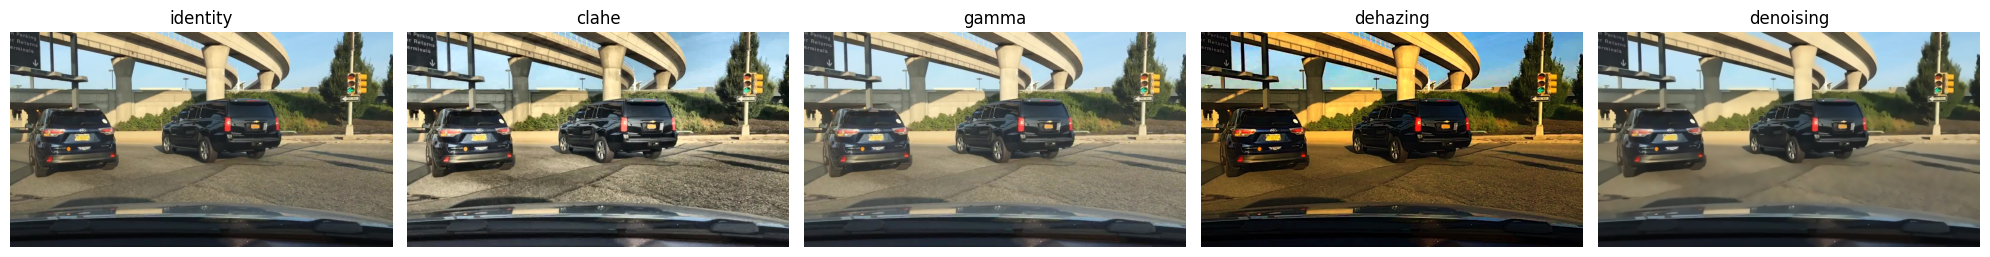

✓ All five enhancement actions executed successfully.


In [6]:
TRAIN_IMAGES_PATH = TRAIN_PATH / "images"
image_files = sorted(
    list(TRAIN_IMAGES_PATH.glob("*.jpg")) +
    list(TRAIN_IMAGES_PATH.glob("*.jpeg")) +
    list(TRAIN_IMAGES_PATH.glob("*.png"))
)

assert len(image_files) > 0, (
    f"No images found in training directory: "
    f"{TRAIN_IMAGES_PATH}"
)

sample_path = image_files[0]
sample_image = cv2.imread(
    str(sample_path)
)

assert sample_image is not None, (
    f"Could not read image: {sample_path}"
)

print("=" * 70)
print("ENHANCEMENT LIBRARY SANITY CHECK")
print("=" * 70)
print(f"Sample image : {sample_path.name}")
print(f"Image path   : {sample_path}")
print(f"Shape        : {sample_image.shape}")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(20, 4)
)

for action_id in ACTION_IDS:

    enhanced = apply_enhancement(
        sample_image,
        action_id
    )
    enhanced_rgb = cv2.cvtColor(
        enhanced,
        cv2.COLOR_BGR2RGB
    )
    axes[action_id].imshow(
        enhanced_rgb
    )
    axes[action_id].set_title(
        ACTION_NAMES[action_id]
    )
    axes[action_id].axis("off")

plt.tight_layout()
plt.show()

print("✓ All five enhancement actions executed successfully.")

Find annotation for an image

In [7]:
def get_label_path(image_path):
    """
    Convert an image path into its corresponding YOLO label path.
    """
    label_path = image_path.parent.parent / "labels" / (
        image_path.stem + ".txt"
    )
    return label_path

test_image = image_files[0]
test_label = get_label_path(test_image)

print(f"Image : {test_image}")
print(f"Label : {test_label}")
print(f"Exists: {test_label.exists()}")

Image : E:\ML_Project\datasets\bdd100k_original_yolo\train\images\0000f77c-6257be58.jpg
Label : E:\ML_Project\datasets\bdd100k_original_yolo\train\labels\0000f77c-6257be58.txt
Exists: True


Robust label path helper

In [8]:
def find_label_for_image(image_path):
    """
    Find the YOLO annotation corresponding to an image.

    Dataset structure:

        train/images  -> train/labels
        valid/images  -> valid/labels
        test/images   -> test/labels
    """

    image_path = Path(image_path)
    split_path = image_path.parent.parent
    label_path = (
        split_path /
        "labels" /
        f"{image_path.stem}.txt"
    )
    if label_path.exists():
        return label_path
    return None
    
train_test_image = sorted(
    list((TRAIN_PATH / "images").glob("*.jpg")) +
    list((TRAIN_PATH / "images").glob("*.jpeg")) +
    list((TRAIN_PATH / "images").glob("*.png"))
)[0]
train_test_label = find_label_for_image(
    train_test_image
)

print("=" * 70)
print("TRAINING IMAGE → LABEL TEST")
print("=" * 70)
print(f"Image : {train_test_image}")
print(f"Label : {train_test_label}")

assert train_test_label is not None, (
    "Training image label could not be found."
)

print("✓ Training annotation found.")

TRAINING IMAGE → LABEL TEST
Image : E:\ML_Project\datasets\bdd100k_original_yolo\train\images\0000f77c-6257be58.jpg
Label : E:\ML_Project\datasets\bdd100k_original_yolo\train\labels\0000f77c-6257be58.txt
✓ Training annotation found.


Read YOLO annotations

In [9]:
def read_yolo_labels(label_path):
    """
    Read YOLO-format labels.

    Each row:
        class_id x_center y_center width height

    Coordinates are normalized to [0, 1].
    """

    labels = []
    if label_path is None or not label_path.exists():
        return labels
    with open(label_path, "r") as f:

        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            labels.append([
                class_id,
                x_center,
                y_center,
                width,
                height
            ])
    return labels
labels_test = read_yolo_labels(test_label)

print(
    f"Number of ground-truth objects: "
    f"{len(labels_test)}"
)

if labels_test:
    print("First annotation:")
    print(labels_test[0])

Number of ground-truth objects: 7
First annotation:
[6, 0.89175, 0.238931, 0.024278, 0.107904]


Convert YOLO boxes to pixel coordinates

In [10]:
def yolo_to_xyxy(
    yolo_box,
    image_width,
    image_height
):
    """
    Convert normalized YOLO coordinates to
    pixel-space [x1, y1, x2, y2].
    """

    class_id, xc, yc, w, h = yolo_box
    xc *= image_width
    yc *= image_height
    w *= image_width
    h *= image_height

    x1 = xc - w / 2
    y1 = yc - h / 2
    x2 = xc + w / 2
    y2 = yc + h / 2

    return [
        float(x1),
        float(y1),
        float(x2),
        float(y2)
    ]


def load_ground_truth(
    label_path,
    image_width,
    image_height
):
    """
    Return ground-truth boxes and class IDs.
    """

    labels = read_yolo_labels(label_path)
    boxes = []
    class_ids = []
    for label in labels:
        class_id = label[0]
        box = yolo_to_xyxy(
            label,
            image_width,
            image_height
        )
        boxes.append(box)
        class_ids.append(class_id)

    return (
        np.array(boxes, dtype=np.float32)
        if boxes
        else np.empty((0, 4), dtype=np.float32),
        np.array(class_ids, dtype=np.int64)
        if class_ids
        else np.empty((0,), dtype=np.int64)
    )

IoU function

In [11]:
def calculate_iou(box1, box2):
    """
    Calculate IoU between two boxes.
    """

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection_width = max(
        0.0,
        x2 - x1
    )
    intersection_height = max(
        0.0,
        y2 - y1
    )
    intersection = (
        intersection_width *
        intersection_height
    )

    area1 = max(
        0.0,
        box1[2] - box1[0]
    ) * max(
        0.0,
        box1[3] - box1[1]
    )
    area2 = max(
        0.0,
        box2[2] - box2[0]
    ) * max(
        0.0,
        box2[3] - box2[1]
    )

    union = area1 + area2 - intersection

    if union <= 0:
        return 0.0

    return intersection / union

Calculate per-image TP/FP/FN

This is the critical part of the oracle calculation.

In [12]:
def calculate_detection_metrics(
    pred_boxes,
    pred_classes,
    gt_boxes,
    gt_classes,
    iou_threshold=0.50
):
    """
    Calculate TP, FP, FN and F1 for one image.

    Matching is:
    - class-aware
    - one prediction can match at most one GT
    - one GT can match at most one prediction
    """

    num_predictions = len(pred_boxes)
    num_ground_truth = len(gt_boxes)

    if num_predictions == 0:
        tp = 0
        fp = 0
        fn = num_ground_truth

        precision = 0.0
        recall = (
            tp / (tp + fn)
            if (tp + fn) > 0
            else 0.0
        )

        f1 = (
            2 * precision * recall /
            (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )

        return tp, fp, fn, precision, recall, f1

    if num_ground_truth == 0:
        tp = 0
        fp = num_predictions
        fn = 0

        return (
            tp,
            fp,
            fn,
            0.0,
            0.0,
            0.0
        )

    matched_predictions = set()
    matched_ground_truth = set()

    candidates = []

    for pred_idx in range(num_predictions):
        for gt_idx in range(num_ground_truth):
            if pred_idx in matched_predictions:
                continue
            if gt_idx in matched_ground_truth:
                continue
            if pred_classes[pred_idx] != gt_classes[gt_idx]:
                continue
            iou = calculate_iou(
                pred_boxes[pred_idx],
                gt_boxes[gt_idx]
            )
            if iou >= iou_threshold:
                candidates.append(
                    (
                        iou,
                        pred_idx,
                        gt_idx
                    )
                )

    candidates.sort(
        key=lambda x: x[0],
        reverse=True
    )
    for iou, pred_idx, gt_idx in candidates:
        if pred_idx in matched_predictions:
            continue
        if gt_idx in matched_ground_truth:
            continue
        matched_predictions.add(pred_idx)
        matched_ground_truth.add(gt_idx)

    tp = len(matched_predictions)
    fp = num_predictions - tp
    fn = num_ground_truth - tp
    precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )
    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    return (
        tp,
        fp,
        fn,
        precision,
        recall,
        f1
    )

YOLO prediction helper

In [13]:
CONF_THRESHOLD = 0.25
IOU_THRESHOLD = 0.50
IMAGE_SIZE = 640

def run_yolo_prediction(image):
    """
    Run the frozen YOLO26n model on an image.
    """

    results = model.predict(
        source=image,
        imgsz=IMAGE_SIZE,
        conf=CONF_THRESHOLD,
        iou=IOU_THRESHOLD,
        verbose=False,
        device=0
    )

    result = results[0]
    if result.boxes is None or len(result.boxes) == 0:

        return (
            np.empty((0, 4), dtype=np.float32),
            np.empty((0,), dtype=np.int64),
            np.empty((0,), dtype=np.float32)
        )
    boxes = result.boxes.xyxy.cpu().numpy()
    classes = (
        result.boxes.cls
        .cpu()
        .numpy()
        .astype(np.int64)
    )
    confidences = (
        result.boxes.conf
        .cpu()
        .numpy()
    )

    return boxes, classes, confidences

Evaluate ONE enhancement on ONE image

In [14]:
def evaluate_single_action(
    image_path,
    action_id
):
    """
    Apply one enhancement and evaluate YOLO26n
    on that single image.
    """

    image = cv2.imread(
        str(image_path)
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    height, width = image.shape[:2]

    # Ground truth
    label_path = find_label_for_image(
        image_path
    )

    gt_boxes, gt_classes = load_ground_truth(
        label_path,
        width,
        height
    )

    enhanced_image = apply_enhancement(
        image,
        action_id
    )

    pred_boxes, pred_classes, pred_conf = (
        run_yolo_prediction(enhanced_image)
    )

    tp, fp, fn, precision, recall, f1 = (
        calculate_detection_metrics(
            pred_boxes,
            pred_classes,
            gt_boxes,
            gt_classes,
            iou_threshold=IOU_THRESHOLD
        )
    )

    return {
        "image": image_path.name,
        "action_id": action_id,
        "action": ACTION_NAMES[action_id],
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Test ONE image with all five actions

In [15]:
pilot_image = image_files[0]
print("=" * 70)
print(f"Testing image: {pilot_image.name}")
print("=" * 70)
pilot_results = []
for action_id in ACTION_IDS:

    result = evaluate_single_action(
        pilot_image,
        action_id
    )
    pilot_results.append(result)
    print(
        f"{result['action']:12s} | "
        f"TP={result['tp']:3d} | "
        f"FP={result['fp']:3d} | "
        f"FN={result['fn']:3d} | "
        f"F1={result['f1']:.4f}"
    )
pilot_df = pd.DataFrame(pilot_results)

print("\n✓ Single-image pilot completed.")

Testing image: 0000f77c-6257be58.jpg
identity     | TP=  6 | FP=  0 | FN=  1 | F1=0.9231
clahe        | TP=  6 | FP=  1 | FN=  1 | F1=0.8571
gamma        | TP=  6 | FP=  0 | FN=  1 | F1=0.9231
dehazing     | TP=  5 | FP=  1 | FN=  2 | F1=0.7692
denoising    | TP=  6 | FP=  0 | FN=  1 | F1=0.9231

✓ Single-image pilot completed.


Determine the oracle action

In [16]:
best_row = pilot_df.loc[
    pilot_df["f1"].idxmax()
]

print("=" * 70)
print("ORACLE RESULT")
print("=" * 70)
print(f"Image         : {best_row['image']}")
print(f"Oracle action : {best_row['action']}")
print(f"Oracle F1     : {best_row['f1']:.4f}")
print("=" * 70)

ORACLE RESULT
Image         : 0000f77c-6257be58.jpg
Oracle action : identity
Oracle F1     : 0.9231


SELECT TRAINING DATA CHUNK

In [17]:
# Change only these values for each run
CHUNK_START = 66000
CHUNK_SIZE = 4000
CHECKPOINT_SIZE = 1000

TRAIN_IMAGES_PATH = TRAIN_PATH / "images"
train_image_files = sorted(
    list(TRAIN_IMAGES_PATH.glob("*.jpg")) +
    list(TRAIN_IMAGES_PATH.glob("*.jpeg")) +
    list(TRAIN_IMAGES_PATH.glob("*.png"))
)

TOTAL_TRAIN_IMAGES = len(train_image_files)

CHUNK_END = min(
    CHUNK_START + CHUNK_SIZE,
    TOTAL_TRAIN_IMAGES
)
chunk_images = train_image_files[
    CHUNK_START:CHUNK_END
]

print("=" * 70)
print("TRAINING DATA CHUNK")
print("=" * 70)
print(f"Total training images : {TOTAL_TRAIN_IMAGES}")
print(f"Chunk start           : {CHUNK_START}")
print(f"Chunk end             : {CHUNK_END}")
print(f"Images in this chunk  : {len(chunk_images)}")
print(f"Actions per image     : {len(ACTION_IDS)}")
print(
    f"YOLO evaluations      : "
    f"{len(chunk_images) * len(ACTION_IDS)}"
)

assert TOTAL_TRAIN_IMAGES == 70000
assert len(chunk_images) == CHUNK_SIZE or CHUNK_END == TOTAL_TRAIN_IMAGES
print(f"Checkpoint size       : {CHECKPOINT_SIZE}")

print("\n✓ Training chunk selected successfully.")

TRAINING DATA CHUNK
Total training images : 70000
Chunk start           : 66000
Chunk end             : 70000
Images in this chunk  : 4000
Actions per image     : 5
YOLO evaluations      : 20000
Checkpoint size       : 1000

✓ Training chunk selected successfully.


CHECKPOINT DIRECTORY

In [18]:
import os
CHECKPOINT_DIR = ORACLE_PATH / "checkpoints"
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)
print("=" * 70)
print("CHECKPOINT DIRECTORY")
print("=" * 70)
print(f"Checkpoint directory : {CHECKPOINT_DIR}")

CHECKPOINT DIRECTORY
Checkpoint directory : E:\ML_Project\results\oracle_labels\checkpoints


Do the oracle evaluation

In [19]:
print("=" * 70)
print("POWER-CUT SAFE ORACLE EVALUATION")
print("=" * 70)
print(f"Images in chunk       : {len(chunk_images)}")
print(f"Actions per image     : {len(ACTION_IDS)}")
print(f"Checkpoint size       : {CHECKPOINT_SIZE}")
print(
    f"Total YOLO evaluations: "
    f"{len(chunk_images) * len(ACTION_IDS)}"
)

print("=" * 70)

for checkpoint_offset in range(
    0,
    len(chunk_images),
    CHECKPOINT_SIZE
):
    checkpoint_start_idx = (
        CHUNK_START +
        checkpoint_offset
    )
    checkpoint_end_idx = min(
        checkpoint_start_idx +
        CHECKPOINT_SIZE,
        CHUNK_END
    )
    checkpoint_filename = (
        f"oracle_checkpoint_"
        f"{checkpoint_start_idx:05d}_"
        f"{checkpoint_end_idx:05d}.csv"
    )
    checkpoint_path = (
        CHECKPOINT_DIR /
        checkpoint_filename
    )
    if checkpoint_path.exists():
        print("\n" + "=" * 70)
        print("CHECKPOINT ALREADY EXISTS — SKIPPING")
        print("=" * 70)
        print(
            f"Images : "
            f"{checkpoint_start_idx} → "
            f"{checkpoint_end_idx}"
        )
        print(
            f"File   : "
            f"{checkpoint_path}"
        )
        continue

    local_start = (
        checkpoint_start_idx -
        CHUNK_START
    )
    local_end = (
        checkpoint_end_idx -
        CHUNK_START
    )

    checkpoint_images = chunk_images[
        local_start:local_end
    ]

    print("\n" + "=" * 70)
    print("STARTING CHECKPOINT")
    print("=" * 70)
    print(
        f"Images : "
        f"{checkpoint_start_idx} → "
        f"{checkpoint_end_idx}"
    )
    print(
        f"Number of images : "
        f"{len(checkpoint_images)}"
    )
    print(
        f"Expected YOLO evaluations : "
        f"{len(checkpoint_images) * len(ACTION_IDS)}"
    )
    print("=" * 70)

    checkpoint_results = []
    
    for image_counter, image_path in enumerate(
        checkpoint_images,
        start=1
    ):
        for action_id in ACTION_IDS:
            result = evaluate_single_action(
                image_path,
                action_id
            )

            checkpoint_results.append(
                result
            )

        if (
            image_counter % 100 == 0
            or
            image_counter == len(checkpoint_images)
        ):
            print(
                f"[{image_counter}/"
                f"{len(checkpoint_images)}] "
                f""
                f"{image_counter / len(checkpoint_images) * 100:.1f}%"
            )

    checkpoint_df = pd.DataFrame(
        checkpoint_results
    )
    expected_checkpoint_rows = (
        len(checkpoint_images) *
        len(ACTION_IDS)
    )
    print("\n" + "=" * 70)
    print("CHECKPOINT EVALUATION COMPLETED")
    print("=" * 70)
    print(
        f"Expected rows : "
        f"{expected_checkpoint_rows}"
    )
    print(
        f"Actual rows   : "
        f"{len(checkpoint_df)}"
    )

    assert (
        len(checkpoint_df)
        ==
        expected_checkpoint_rows
    ), (
        "Checkpoint row count mismatch!"
    )
    checkpoint_df.to_csv(
        checkpoint_path,
        index=False
    )
    print("\n" + "=" * 70)
    print("✓ CHECKPOINT SAVED")
    print("=" * 70)
    print(
        f"Images : "
        f"{checkpoint_start_idx} → "
        f"{checkpoint_end_idx}"
    )
    print(
        f"Rows   : "
        f"{len(checkpoint_df)}"
    )
    print(
        f"File   : "
        f"{checkpoint_path}"
    )

print("\n" + "=" * 70)
print("✓ ALL CHECKPOINTS FOR THIS CHUNK COMPLETED")
print("=" * 70)

POWER-CUT SAFE ORACLE EVALUATION
Images in chunk       : 4000
Actions per image     : 5
Checkpoint size       : 1000
Total YOLO evaluations: 20000

STARTING CHECKPOINT
Images : 66000 → 67000
Number of images : 1000
Expected YOLO evaluations : 5000
[100/1000] 10.0%
[200/1000] 20.0%
[300/1000] 30.0%
[400/1000] 40.0%
[500/1000] 50.0%
[600/1000] 60.0%
[700/1000] 70.0%
[800/1000] 80.0%
[900/1000] 90.0%
[1000/1000] 100.0%

CHECKPOINT EVALUATION COMPLETED
Expected rows : 5000
Actual rows   : 5000

✓ CHECKPOINT SAVED
Images : 66000 → 67000
Rows   : 5000
File   : E:\ML_Project\results\oracle_labels\checkpoints\oracle_checkpoint_66000_67000.csv

STARTING CHECKPOINT
Images : 67000 → 68000
Number of images : 1000
Expected YOLO evaluations : 5000
[100/1000] 10.0%
[200/1000] 20.0%
[300/1000] 30.0%
[400/1000] 40.0%
[500/1000] 50.0%
[600/1000] 60.0%
[700/1000] 70.0%
[800/1000] 80.0%
[900/1000] 90.0%
[1000/1000] 100.0%

CHECKPOINT EVALUATION COMPLETED
Expected rows : 5000
Actual rows   : 5000

✓ CHECKP

Generate pilot oracle labels

In [20]:
# ============================================================
# CELL 19 — MERGE CHECKPOINTS AND GENERATE ORACLE LABELS
# ============================================================

print("=" * 70)
print("MERGING CHECKPOINTS")
print("=" * 70)


# ============================================================
# FIND ALL CHECKPOINTS BELONGING TO THIS CHUNK
# ============================================================

checkpoint_files = []

for checkpoint_start in range(
    CHUNK_START,
    CHUNK_END,
    CHECKPOINT_SIZE
):

    checkpoint_end = min(
        checkpoint_start + CHECKPOINT_SIZE,
        CHUNK_END
    )

    checkpoint_path = (
        CHECKPOINT_DIR /
        f"oracle_checkpoint_"
        f"{checkpoint_start:05d}_"
        f"{checkpoint_end:05d}.csv"
    )

    if checkpoint_path.exists():
        checkpoint_files.append(
            checkpoint_path
        )


print(
    f"Checkpoint files found : "
    f"{len(checkpoint_files)}"
)


assert len(checkpoint_files) > 0, (
    "No checkpoint files found."
)


# ============================================================
# LOAD ALL CHECKPOINTS
# ============================================================

checkpoint_dfs = []

for checkpoint_file in checkpoint_files:

    print(
        f"Loading: "
        f"{checkpoint_file.name}"
    )

    df = pd.read_csv(
        checkpoint_file
    )

    checkpoint_dfs.append(
        df
    )


# ============================================================
# COMBINE
# ============================================================

chunk_results_df = pd.concat(
    checkpoint_dfs,
    ignore_index=True
)


expected_rows = (
    len(chunk_images) *
    len(ACTION_IDS)
)


print("\n" + "=" * 70)
print("CHECKPOINTS MERGED")
print("=" * 70)

print(
    f"Expected rows : "
    f"{expected_rows}"
)

print(
    f"Actual rows   : "
    f"{len(chunk_results_df)}"
)


assert len(chunk_results_df) == expected_rows


# ============================================================
# GENERATE ORACLE LABELS
# ============================================================

chunk_oracle_rows = []


for image_name, group in chunk_results_df.groupby(
    "image"
):

    group = group.sort_values(
        by="f1",
        ascending=False
    )

    best = group.iloc[0]


    chunk_oracle_rows.append({

        "image": image_name,

        "oracle_action_id": int(
            best["action_id"]
        ),

        "oracle_action": best["action"],

        "oracle_f1": float(
            best["f1"]
        )
    })


chunk_oracle_df = pd.DataFrame(
    chunk_oracle_rows
)


print("\n" + "=" * 70)
print("ORACLE LABELS GENERATED")
print("=" * 70)

print(
    f"Images processed : "
    f"{len(chunk_oracle_df)}"
)


assert (
    len(chunk_oracle_df)
    ==
    len(chunk_images)
)


print("\n✓ One Oracle label generated per image.")

MERGING CHECKPOINTS
Checkpoint files found : 10
Loading: oracle_checkpoint_50000_51000.csv
Loading: oracle_checkpoint_51000_52000.csv
Loading: oracle_checkpoint_52000_53000.csv
Loading: oracle_checkpoint_53000_54000.csv
Loading: oracle_checkpoint_54000_55000.csv
Loading: oracle_checkpoint_55000_56000.csv
Loading: oracle_checkpoint_56000_57000.csv
Loading: oracle_checkpoint_57000_58000.csv
Loading: oracle_checkpoint_58000_59000.csv
Loading: oracle_checkpoint_59000_60000.csv

CHECKPOINTS MERGED
Expected rows : 50000
Actual rows   : 50000

ORACLE LABELS GENERATED
Images processed : 10000

✓ One Oracle label generated per image.


Inspect oracle distribution

In [21]:
# ============================================================
# CELL 20 — ORACLE ACTION DISTRIBUTION
# ============================================================

distribution = (
    chunk_oracle_df["oracle_action"]
    .value_counts()
    .reindex(
        list(ACTION_NAMES.values()),
        fill_value=0
    )
)

print("=" * 70)
print("ORACLE ACTION DISTRIBUTION")
print("=" * 70)

print(distribution)

print("\nPercentages:")

print(
    (
        distribution /
        len(chunk_oracle_df) *
        100
    ).round(2)
)

ORACLE ACTION DISTRIBUTION
oracle_action
identity     3678
clahe        2160
gamma        1211
dehazing     1303
denoising    1648
Name: count, dtype: int64

Percentages:
oracle_action
identity     36.78
clahe        21.60
gamma        12.11
dehazing     13.03
denoising    16.48
Name: count, dtype: float64


Save the results

In [22]:
# ============================================================
# CELL 21 — SAVE FINAL ORACLE CHUNK
# ============================================================

assert len(chunk_results_df) == (
    len(chunk_images) * len(ACTION_IDS)
)

assert len(chunk_oracle_df) == len(
    chunk_images
)

scores_path = (
    ORACLE_PATH /
    f"oracle_scores_{CHUNK_START:05d}_{CHUNK_END:05d}.csv"
)

labels_path = (
    ORACLE_PATH /
    f"oracle_labels_{CHUNK_START:05d}_{CHUNK_END:05d}.csv"
)


chunk_results_df.to_csv(
    scores_path,
    index=False
)

chunk_oracle_df.to_csv(
    labels_path,
    index=False
)


print("=" * 70)
print("ORACLE CHUNK SAVED")
print("=" * 70)

print("\n✓ Action scores:")
print(scores_path)

print("\n✓ Oracle labels:")
print(labels_path)

ORACLE CHUNK SAVED

✓ Action scores:
E:\ML_Project\results\oracle_labels\oracle_scores_50000_60000.csv

✓ Oracle labels:
E:\ML_Project\results\oracle_labels\oracle_labels_50000_60000.csv
